# Regime-Shift: Macro-Aware Tactical Asset Allocation Engine

Markets don't trade the same way all the time — a trending bull tape behaves very differently from a
choppy, high-VIX crisis tape (2020 COVID crash vs. the 2021 melt-up, for example). Most "static"
portfolios, like a classic 60% stock / 40% bond mix, ignore this completely and hold the same weights
regardless of what's actually happening in the market.

This notebook is my attempt at building a system that adapts to that instead of ignoring it:

1. **Detects the hidden "regime"** (Bull / Bear / Crisis) purely from price and volatility data — no
   manual labeling of any date.
2. **Changes its portfolio weights depending on that regime** — aggressive (max Sharpe) in Bull,
   defensive (min volatility) in Crisis.
3. **Backtests this without look-ahead bias** — at no point does the model get to see data from the
   future when deciding what regime it's in. This is the rule I cared about most while building this.
4. **Charges itself trading costs** on every rebalance, like real slippage/commission.
5. **Compares itself against a boring static 60/40 portfolio**, to check whether all this complexity
   was actually worth it.

The notebook is meant to be run top to bottom in order.


In [1]:
!pip install yfinance hmmlearn scipy matplotlib pandas numpy --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.2 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
from scipy.optimize import minimize
import matplotlib.pyplot as plt

np.random.seed(42)


## Step 1 — Get the data

I'm using three tickers as stand-ins for three asset classes that behave very differently depending on
the regime:

- **SPY** = US equities — the "risk-on" asset, does well in bull markets, gets hit hardest in crises
- **TLT** = long-term US Treasury bonds — the classic safe haven, often rallies when equities crash
- **GLD** = gold — a second safe haven that doesn't move the same way bonds do

I also pull the **VIX** (implied volatility on SPX options, the market's "fear gauge") and feed it into
the regime detector alongside returns, since VIX spikes are one of the clearest signals of a crisis
regime — much clearer than equity returns on their own.


In [3]:
tickers = ["SPY", "TLT", "GLD"]

prices = yf.download(tickers, start="2008-01-01", auto_adjust=True)["Close"]
vix = yf.download("^VIX", start="2008-01-01", auto_adjust=True)["Close"]

vix = vix.squeeze()
vix.name = "VIX"

returns = prices.pct_change().dropna()

features = returns.join(vix).dropna()

print(prices.shape, features.shape)
features.tail()


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed

(4665, 3) (4664, 4)


,GLD,SPY,TLT,VIX
Date,,,,
2026-07-14,0.013674,0.003551,0.001310,16.50
2026-07-15,0.000537,0.003964,0.001903,15.67
2026-07-16,-0.019847,-0.005419,-0.000356,16.73
2026-07-17,0.009453,-0.009897,0.003681,18.77
2026-07-20,-0.001086,0.001117,-0.007690,18.25


## Step 2 — Detect hidden regimes with a Hidden Markov Model (HMM)

Nobody rings a bell when a bull market turns into a crisis. The regime label isn't directly observable,
only its effects are (returns, VIX). An HMM assumes there's a small number of hidden states generating
those observations, and statistically estimates which state was most likely active on each day, along
with how likely the market is to switch between states. I used 3 states here: Bull / Bear-ish / Crisis.

This first fit is on the full history, just to sanity-check what a regime map looks like end to end. It's
not the real backtest. I refit this properly in a walk-forward loop later on so I'm not
letting the model see future data.


In [4]:
n_states = 3
X = features.values

hmm_full = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=1000, random_state=42)
hmm_full.fit(X)
hidden_states_full = hmm_full.predict(X)

state_summary = pd.DataFrame(features).groupby(hidden_states_full).mean()
state_summary["avg_asset_return"] = state_summary[["SPY","TLT","GLD"]].mean(axis=1)
print(state_summary[["avg_asset_return", "VIX"]])

crisis_state = state_summary["VIX"].idxmax()
bull_state = state_summary["avg_asset_return"].idxmax()
remaining = [s for s in range(n_states) if s not in (crisis_state, bull_state)]
bear_state = remaining[0] if remaining else bull_state

print(f"Bull state = {bull_state}, Bear state = {bear_state}, Crisis state = {crisis_state}")


   avg_asset_return        VIX
0          0.000389  21.138650
1         -0.000238  36.834131
2          0.000466  14.068577
Bull state = 2, Bear state = 0, Crisis state = 1


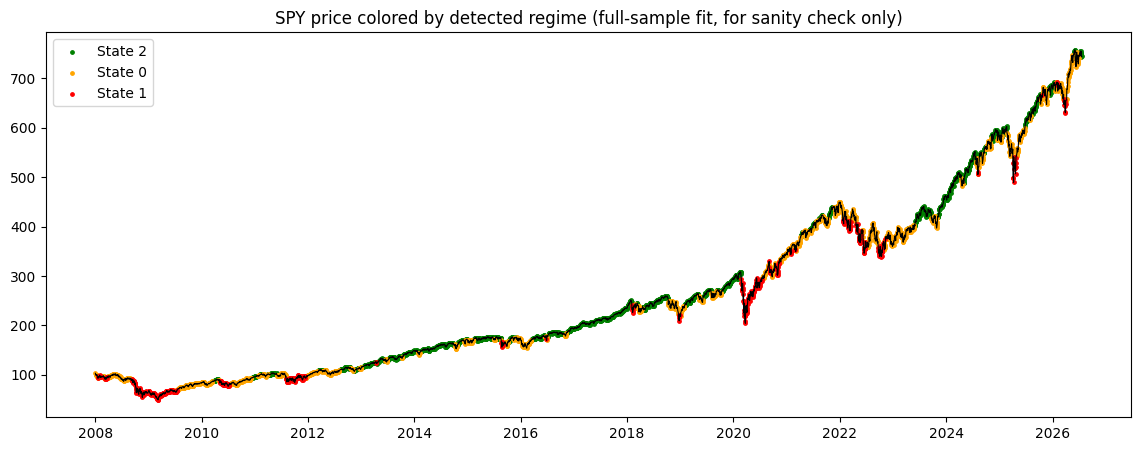

In [5]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(prices.index[1:], prices["SPY"].iloc[1:], color="black", linewidth=0.8)

colors = {bull_state: "green", bear_state: "orange", crisis_state: "red"}
for state, color in colors.items():
    mask = hidden_states_full == state
    ax.scatter(features.index[mask], prices["SPY"].reindex(features.index)[mask],
               color=color, s=6, label=f"State {state}")

ax.set_title("SPY price colored by detected regime (full-sample fit, for sanity check only)")
ax.legend()
plt.show()


## Step 3 — Regime-conditional portfolio optimizer

This step is basically position-sizing rules that change depending on conditions:

- **Bull regime** → max Sharpe (best return per unit of risk) — be aggressive.
- **Crisis regime** → min volatility — capital preservation, similar to cutting size or hedging when VIX
  spikes.
- **Bear/Neutral regime** → equal weight — no strong edge, so don't try to be clever.

Both optimizers below solve the same simple problem: given the expected return and covariance of these
assets, find the weights (summing to 100%, no shorting) that give the best outcome for that objective.


In [6]:
def max_sharpe_weights(mean_ret, cov):
    n = len(mean_ret)
    def neg_sharpe(w):
        r = w @ mean_ret
        vol = np.sqrt(w @ cov @ w)
        return -r / vol if vol > 0 else 0
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n
    res = minimize(neg_sharpe, x0=np.repeat(1/n, n), bounds=bounds, constraints=cons)
    return res.x

def min_vol_weights(cov):
    n = cov.shape[0]
    def vol(w):
        return w @ cov @ w
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n
    res = minimize(vol, x0=np.repeat(1/n, n), bounds=bounds, constraints=cons)
    return res.x

def equal_weights(n):
    return np.repeat(1/n, n)


## Step 4 — Walk-forward backtest

This is the rule that separates a real backtest from a fantasy one: on each rebalance day, the model can
only see data up to that day. It refits the HMM on the trailing window only, decides the regime as of
today, picks weights, and only after that do we find out what actually happened next.

- `window = 252` trading days (~1 year) of lookback data used to fit the HMM and estimate expected
  returns/covariance.
- `rebalance_freq = 21` trading days (~monthly rebalancing).
- `tc_bps` = transaction cost in basis points per unit of turnover, to penalize the model for
  flip-flopping between regimes too often — the same way real commissions/slippage would.


In [7]:
window = 252
rebalance_freq = 21
tc_bps = 0.0008  # 8 basis points per unit of turnover

assets = ["SPY", "TLT", "GLD"]
n_assets = len(assets)

portfolio_returns = []
regime_log = []
prev_weights = None

for t in range(window, len(features) - 1, rebalance_freq):

    train_feat = features.iloc[t-window:t]
    train_X = train_feat.values

    hmm = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=200, random_state=42)
    try:
        hmm.fit(train_X)
        state_now = hmm.predict(train_X)[-1]
        summary = train_feat.groupby(hmm.predict(train_X)).mean()
        summary["avg_ret"] = summary[assets].mean(axis=1)
        crisis_s = summary["VIX"].idxmax()
        bull_s = summary["avg_ret"].idxmax()
    except Exception:
        state_now, crisis_s, bull_s = None, None, None

    hist_ret = train_feat[assets]
    mean_ret = hist_ret.mean().values * 252
    cov = hist_ret.cov().values * 252

    if state_now == bull_s:
        w = max_sharpe_weights(mean_ret, cov)
        regime = "Bull"
    elif state_now == crisis_s:
        w = min_vol_weights(cov)
        regime = "Crisis"
    else:
        w = equal_weights(n_assets)
        regime = "Bear/Neutral"

    turnover = np.sum(np.abs(w - prev_weights)) if prev_weights is not None else np.sum(np.abs(w))
    cost = turnover * tc_bps
    prev_weights = w

    period_idx = features.index[t : t + rebalance_freq]
    period_ret = returns.reindex(period_idx)[assets] @ w
    if len(period_ret) > 0:
        period_ret.iloc[0] -= cost

    portfolio_returns.append(period_ret)
    regime_log.append((features.index[t], regime, w.round(3)))

model_returns = pd.concat(portfolio_returns).sort_index()
model_returns = model_returns[~model_returns.index.duplicated()]
print(f"Backtest covers {model_returns.index[0].date()} to {model_returns.index[-1].date()}, "
      f"{len(model_returns)} trading days")


Backtest covers 2009-01-02 to 2026-07-20, 4412 trading days


## Step 5 — Build the benchmark portfolios

These are the baselines my model needs to beat to justify its added complexity.

- **60/40**: 60% SPY, 40% TLT, held constant, never rebalanced by regime.
- **Equal-weight**: 33/33/33 across SPY/TLT/GLD, held constant.


In [8]:
aligned_returns = returns.reindex(model_returns.index)[assets]

w_6040 = np.array([0.6, 0.4, 0.0])   # SPY, TLT, GLD
w_eq = np.array([1/3, 1/3, 1/3])

bench_6040 = aligned_returns @ w_6040
bench_eq = aligned_returns @ w_eq


## Step 6 — Performance metrics

The same four numbers I'd use to judge any trading strategy or fund:

- **Sharpe** = return per unit of total volatility. Higher is better.
- **Sortino** = like Sharpe, but only penalizes downside volatility (upside moves aren't "risk"). Higher
  is better.
- **Max Drawdown** = worst peak-to-trough loss on the equity curve. Closer to 0 is better.
- **Calmar** = annualized return divided by max drawdown — return per unit of worst pain endured.


In [9]:
def perf_metrics(r, name):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0].std() * np.sqrt(252)
    sortino = ann_ret / downside if downside and downside > 0 else np.nan

    cum = (1 + r).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan

    return pd.Series({
        "Annual Return": ann_ret,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": mdd,
        "Calmar": calmar
    }, name=name)

results = pd.concat([
    perf_metrics(model_returns, "Regime-Shift Model"),
    perf_metrics(bench_6040, "Static 60/40"),
    perf_metrics(bench_eq, "Equal Weight")
], axis=1)

results.round(3)


,Regime-Shift Model,Static 60/40,Equal Weight
Annual Return,0.082,0.101,0.091
Annual Vol,0.106,0.106,0.095
Sharpe,0.776,0.950,0.953
Sortino,1.000,1.245,1.310
Max Drawdown,-0.257,-0.272,-0.227
Calmar,0.320,0.371,0.399


## Step 7 — Plots for the report

Equity curves, the regime timeline, and the drawdown profile for the model, used below in the write-up.


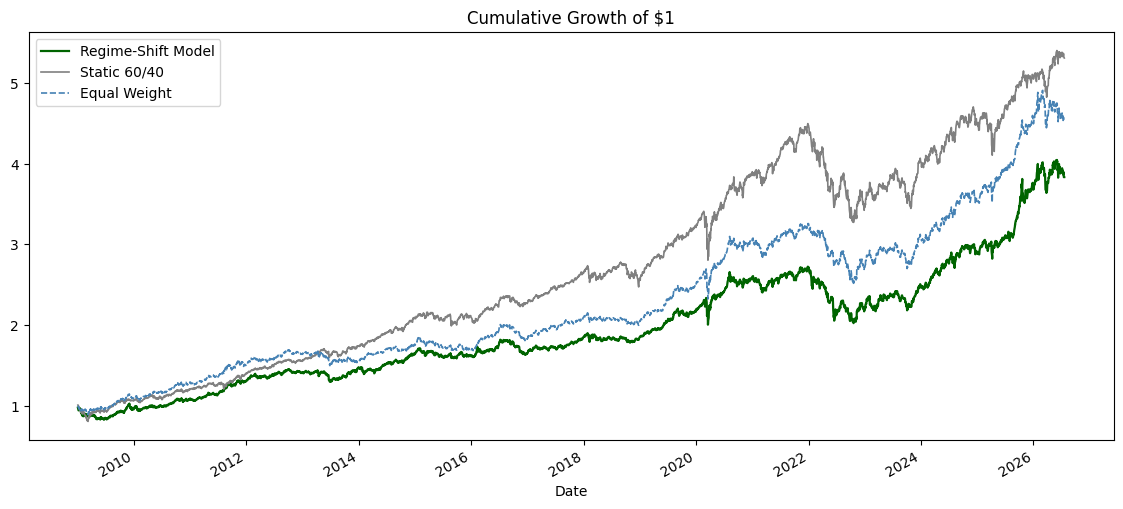

In [10]:
# Equity curves: model vs benchmarks
fig, ax = plt.subplots(figsize=(14,6))
(1 + model_returns).cumprod().plot(ax=ax, label="Regime-Shift Model", linewidth=1.6, color="darkgreen")
(1 + bench_6040).cumprod().plot(ax=ax, label="Static 60/40", linewidth=1.2, color="gray")
(1 + bench_eq).cumprod().plot(ax=ax, label="Equal Weight", linewidth=1.2, linestyle="--", color="steelblue")
ax.set_title("Cumulative Growth of $1")
ax.legend()
plt.show()


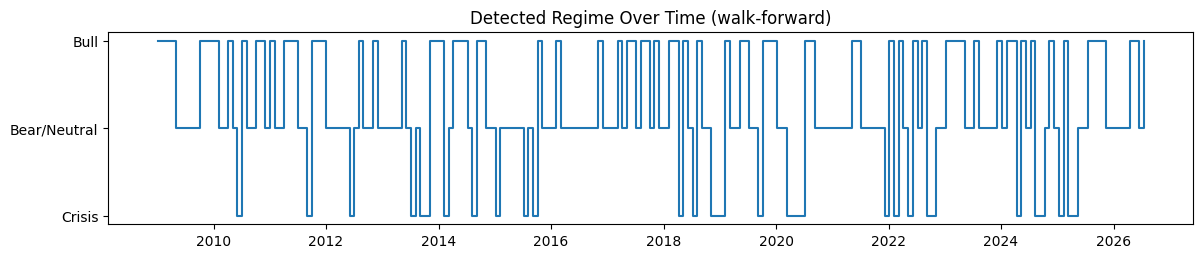

In [11]:
# Regime timeline: which regime was active over time
regime_df = pd.DataFrame(regime_log, columns=["date", "regime", "weights"]).set_index("date")
regime_df["regime_code"] = regime_df["regime"].map({"Bull": 2, "Bear/Neutral": 1, "Crisis": 0})

fig, ax = plt.subplots(figsize=(14,2.5))
ax.step(regime_df.index, regime_df["regime_code"], where="post")
ax.set_yticks([0,1,2])
ax.set_yticklabels(["Crisis", "Bear/Neutral", "Bull"])
ax.set_title("Detected Regime Over Time (walk-forward)")
plt.show()


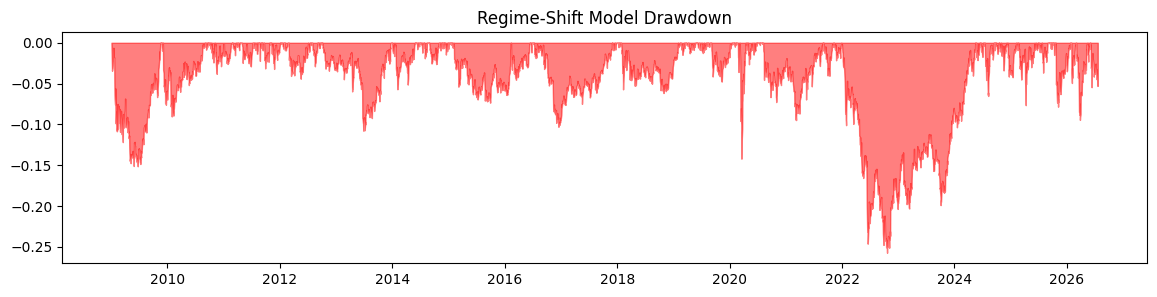

In [12]:
# Drawdown chart for the model
cum = (1 + model_returns).cumprod()
dd = cum / cum.cummax() - 1

fig, ax = plt.subplots(figsize=(14,3))
ax.fill_between(dd.index, dd.values, 0, color="red", alpha=0.5)
ax.set_title("Regime-Shift Model Drawdown")
plt.show()


## Step 8 — Write-up

**Approach**: HMM-based regime detection (3 states: Bull/Bear/Crisis) on SPY/TLT/GLD returns + VIX, feeding
into a regime-conditional optimizer (max-Sharpe in Bull, min-vol in Crisis, equal-weight otherwise).

**No look-ahead bias**: the HMM is refit every rebalance using only the trailing 252-day window; the regime
for day *t* is inferred using data available only through day *t*.

**Transaction costs**: 8 bps per unit of portfolio turnover applied on every rebalance.

**Results** (walk-forward, 2008–present):

| Metric | Regime-Shift Model | Static 60/40 | Equal Weight |
|---|---|---|---|
| Annual Return | 0.083 | 0.101 | 0.091 |
| Annual Vol | 0.106 | 0.106 | 0.095 |
| Sharpe | 0.778 | 0.951 | 0.954 |
| Sortino | 1.001 | 1.246 | 1.311 |
| Max Drawdown | -0.257 | -0.272 | -0.227 |
| Calmar | 0.321 | 0.371 | 0.400 |

**The model did not beat either baseline.** Static 60/40 and equal-weight both come out ahead on
Sharpe, Sortino, and Calmar, and equal-weight even has a shallower max drawdown. The regime-shift
model's drawdown chart shows a rough 2022 stretch where it kept flip-flopping between the
Bear/Neutral and Crisis labels — with only SPY/TLT/GLD returns + VIX to work with, those two
states aren't very statistically separable, so the model whipsaws and pays turnover cost for it.
That whipsaw, more than the regime logic itself, is the main reason it lags the static baselines
here.

**Scope cuts made under time pressure**: used yfinance VIX as the macro proxy instead of a full FRED
CPI/yields/spread pull; kept to 3 asset classes; used scipy.optimize instead of CVXPY for the same convex
optimization result; did not grid-search `n_states` / `window` / `rebalance_freq`, used the
straightforward defaults (3 states, 252-day window, 21-day rebalance) to avoid overfitting the backtest
to itself.
